Installing Libraries

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

Importing data

In [33]:
train_dir = "C:/Users/jorda/OneDrive/Desktop/Code/Data/fruit_veg/train"
test_dir = "C:/Users/jorda/OneDrive/Desktop/Code/Data/fruit_veg/test"
validation_dir = "C:/Users/jorda/OneDrive/Desktop/Code/Data/fruit_veg/validation"

In [34]:
BATCH_SIZE = 32
IMG_SIZE = (180, 180) # Resizing all images to 180x180

In [35]:
# Load Training Data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=123, #starting using 123 as random number generator
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load Validation Data
val_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Extract and print class names to verify
class_names = train_ds.class_names
print("Classes found:", class_names)

Found 3115 files belonging to 36 classes.
Found 351 files belonging to 36 classes.
Classes found: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


In [36]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# We will include the rescaling layer directly inside our model below.

CNN Model

In [ ]:
num_classes = len(class_names)

model = keras.Sequential([
    
    # It randomly turns 20% of your images black and white during training
    layers.RandomBrightness(0.2), # Randomly changes lighting
    layers.RandomContrast(0.2),   # Randomly shifts colors
    
    # 1. Rescale inputs from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # 2. First Convolutional block
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    # 3. Second Convolutional block
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    # 4. Third Convolutional block
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    # 5. Flatten the 2D matrices into a 1D vector
    layers.Flatten(),
    
    # 6. Dense Layer (Hidden Network)
    layers.Dense(128, activation='relu'),
    
    # 7. Output Layer (One neuron per class)
    layers.Dense(num_classes)
])

# View the structure of your network
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_brightness_1             │ ?                      │   0 (unbuilt) │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(
    optimizer='adam', #Other optimizers include: SGD (Stochastic Gradient Descent), RMSprop
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [39]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10


c:\Users\jorda\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


98/98 ━━━━━━━━━━━━━━━━━━━━ 19s 128ms/step - accuracy: 0.0803 - loss: 3.3081 - val_accuracy: 0.1966 - val_loss: 2.7493
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.2205 - loss: 2.6524 - val_accuracy: 0.3818 - val_loss: 2.1181
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.3496 - loss: 2.2035 - val_accuracy: 0.5897 - val_loss: 1.4787
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.4283 - loss: 1.9018 - val_accuracy: 0.7236 - val_loss: 1.0870
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.5403 - loss: 1.5315 - val_accuracy: 0.7806 - val_loss: 0.8379
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.6735 - loss: 1.1189 - val_accuracy: 0.8746 - val_loss: 0.5082
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.7955 - loss: 0.6764 - val_accuracy: 0.9174 - val_loss: 0.3598
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.8857 - loss: 0.3747 - val_accuracy: 0.937

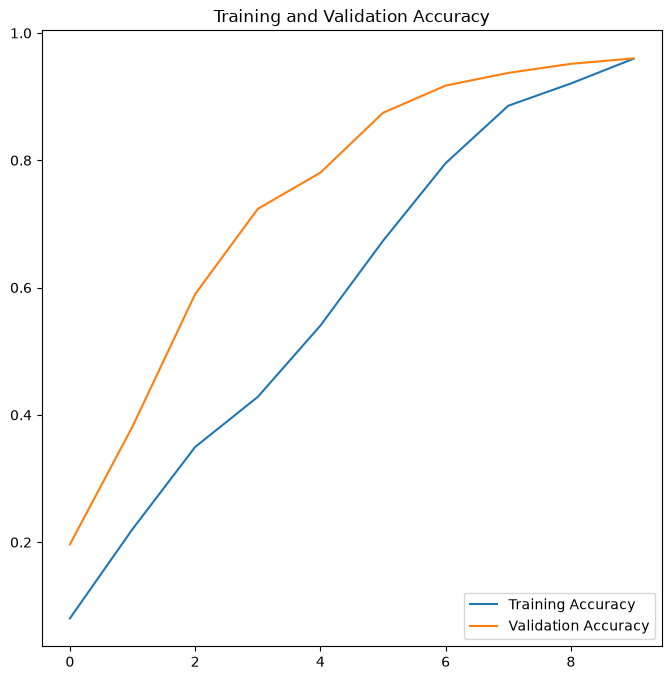

In [40]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

In [41]:
# Pick an image from your test directory
fruit_type = "banana".lower()
test_image_path = f"{test_dir}/{fruit_type}/Image_2.jpg"

img = keras.utils.load_img(test_image_path, target_size=IMG_SIZE)
img_array = keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    f"This image most likely belongs to {class_names[np.argmax(score)]} "
    f"with a {100 * np.max(score):.2f} percent confidence."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
This image most likely belongs to ginger with a 40.60 percent confidence.
